In [1]:
from VSP_Auxiliary import *
import VSP_Lib
from astropy.table import Table
from matplotlib import pyplot as plt

In [32]:
def screen_sed_data(tbl):
    # 筛选Vizier SED数据
    #print(np.array(sed['_tabname'].value))
    cut = \
     (tbl['_tabname']=='II/335/galex_ais') | \
     (tbl['_tabname']=='I/355/gaiadr3') | \
     (tbl['_tabname']=='II/349/ps1') | \
    ((tbl['_tabname']=='II/336/apass9') & (tbl['sed_filter']=='Johnson:B')) | \
    ((tbl['_tabname']=='II/336/apass9') & (tbl['sed_filter']=='Johnson:V')) | \
     (tbl['_tabname']=='II/349/ps1') | \
     (tbl['_tabname']=='I/305/out') | \
     (tbl['_tabname']=='II/328/allwise') | \
     (tbl['_tabname']=='J/ApJS/249/18/table2') | \
     (tbl['_tabname']=='II/363/unwise') | \
     (tbl['_tabname']=='II/365/catwise') | \
     (tbl['_tabname']=='II/378/xmmom6s') | \
     (tbl['_tabname']=='II/368/sstsl2')
    #print(tbl[cut]['sed_filter'].value)
    return tbl[cut]

# 测试
#sed=Table.read('./Temp/sed_vizier.csv')
#tbl = screen_sed_data(sed)
#tbl

_RAJ2000,_DEJ2000,_tabname,_ID,_time(TCB),sed_freq,sed_flux,sed_eflux,sed_filter
float64,float64,str22,str64,float64,float64,float64,float64,str16
103.154951,24.606188,I/305/out,"GSC2.3===N8G0006450&-c=103.154951 +24.606188,eq=J2000&-c.rs=0.00",--,382540.0,0.00188,0.00075,POSS-II:i
103.154951,24.606188,I/305/out,"GSC2.3===N8G0006450&-c=103.154951 +24.606188,eq=J2000&-c.rs=0.00",--,468430.0,0.00162,0.00063,POSS-II:F
103.154951,24.606188,I/305/out,"GSC2.3===N8G0006450&-c=103.154951 +24.606188,eq=J2000&-c.rs=0.00",--,640580.0,0.002,0.00077,POSS-II:J
103.154951,24.606188,I/305/out,"GSC2.3===N8G0006450&-c=103.154951 +24.606188,eq=J2000&-c.rs=0.00",--,674900.0,0.00541,0.0022,Johnson:B
103.154936798,24.606181976,I/355/gaiadr3,"-c=103.15496005010 +24.60614166658,eq=ICRS&-c.rs=0.004",--,393400.0,0.00161,0.00014,GAIA/GAIA3:Grp
...,...,...,...,...,...,...,...,...
103.15495947,24.60614404,II/349/ps1,"-c=103.154959470 +24.606144040,eq=J2000&-c.rs=0.004",2455977.500104,628200.0,0.00263,0.00023,PAN-STARRS/PS1:g
103.154943985,24.606163201,II/363/unwise,"-c=103.1549440 +24.6061632,eq=J2000&-c.rs=0.004",--,65172.0,0.000188,6e-06,WISE:W2
103.154943985,24.606163201,II/363/unwise,"-c=103.1549440 +24.6061632,eq=J2000&-c.rs=0.004",--,89490.0,0.000344,3e-06,WISE:W1


In [21]:
def get_photometry(coord, radius=1.5, path='./Temp/'):
    ra_deg = coord.ra.value
    dec_deg = coord.dec.value
    url = f'http://vizier.u-strasbg.fr/viz-bin/sed?-c={ra_deg}%20{dec_deg}&-c.rs={radius}'
    #print(url)
    name = 'sed_vizier_download.vot'
    # print(path+name)
    if download_url(url, path+name, overwrite=True):
        try:
            sed=Table.read(path+name)
            if '_tab1_29' in sed.colnames:
                sed.rename_column('_tab1_29','_time(TCB)')
            if '_tab1_30' in sed.colnames:
                sed.remove_column('_tab1_30')
            if path is not None:
                sed.write(path+'sed_vizier.csv',format='ascii.csv', overwrite=True)
                print('SED data from Vizier has been saved to', path+'sed_vizier.csv')
            print('SED data legth:',len(sed))
            #os.remove(path+name)
        except:
            sed = False
    else:
        sed = False
    return sed
    
# 测试
#c = SkyCoord('06 52 37.19 +24 36 22.1', unit=(u.hourangle, u.deg), frame='fk5')
#get_photometry(c, radius=1.5, path='./Temp/')

In [22]:
# sc = VSP_Lib.query_SIMBAD_name('3C 273') # 通过名称在线查询SIMBAD
# coord = VSP_Lib.extract_radec(sc) # 从SIMBAD script中提取坐标
# create_dir('./Temp/3C_273/')
# get_photometry(coord, radius=1.5, path='./Temp/3C_273/') # 从Vizier上在线获取SED数据，保存在path文件夹下(统一为sed_vizier.csv)
# sed_tbl = Table.read('./Temp/3C_273/sed_vizier.csv') # 读取下载好的sed数据
# print(screen_sed_data(sed_tbl))

>>> main type : BLLac 
>>> otypes    : AGN,Sy1,Bla,BLL,QSO,smm,NIR,V*,MIR,*,AG?,G,IR,Opt,Q?,Rad,UV,X,gam,var
ra dec: 12 29 06.6998257176 +02 03 08.597629980
SED data from Vizier has been saved to ./Temp/3C_273/sed_vizier.csv
SED data legth: 1370
   _RAJ2000      _DEJ2000      _tabname    ... sed_flux sed_eflux   sed_filter  
-------------- ------------ -------------- ... -------- --------- --------------
     187.27791     2.052326      I/305/out ...    0.034     0.014      POSS-II:i
     187.27791     2.052326      I/305/out ...   0.0273     0.011      POSS-II:F
     187.27791     2.052326      I/305/out ...   0.0395     0.016      POSS-II:J
     187.27791     2.052326      I/305/out ...    0.025    0.0097      Johnson:B
187.2779159405 2.0523882306  I/355/gaiadr3 ...   0.0257    0.0002 GAIA/GAIA3:Grp
           ...          ...            ... ...      ...       ...            ...
  187.27806806   2.05247806 II/378/xmmom6s ...   0.0228       0.0    XMM-OT:UVW1
  187.27806806   2.052478

In [49]:
def process_flux(data,save_path=None):
    #print(data)
    # 转换成流量
    # 读取频率GHz, 流量Jy
    sed_freq = np.array(data['sed_freq'].tolist(),dtype=np.float64)
    sed_flux = np.array(data['sed_flux'].tolist(),dtype=np.float64)
    sed_eflux = np.array(data['sed_eflux'].tolist(),dtype=np.float64)
    filterdata = np.array(data['sed_filter'])
    #print(filterdata)
    
    vizr_wave = 2.998*np.power(10,9)/(sed_freq) # A            2.998*power(10,14)/("_sed_freq"*power(10,9))
    vizr_flux = sed_flux*sed_freq*np.power(10,9)*u.Jy*u.Hz    # ("_sed_flux")*("_sed_freq"*power(10,9))
    vizr_eflux = sed_eflux*sed_freq*np.power(10,9)*u.Jy*u.Hz  # Jy = 10-26 J/(s m2 Hz) = 10-23 erg/(s m2 Hz)
    vizr_filter = filterdata
    
    vizr_flux2 = vizr_flux.to(u.erg / (u.cm ** 2 * u.s))
    vizr_eflux2 = vizr_eflux.to(u.erg / (u.cm ** 2 * u.s))
    #print(vizr_eflux2)
    
    tbl = Table(names=['vizr_wave','vizr_flux','vizr_eflux','vizr_filter','vizier_tabname'], \
               dtype=['f8','f8','f8','S22','S24'], units=[u.angstrom,u.erg / (u.cm ** 2 * u.s),u.erg / (u.cm ** 2 * u.s),None,None])
    for i in range(len(data)):
        row = [vizr_wave[i],vizr_flux2[i],vizr_eflux2[i],vizr_filter[i],np.array(data['_tabname'])[i]]
        tbl.add_row(row)
    if save_path is not None:
        tbl.write(save_path,format='ascii.csv',overwrite=True)
        print('processed sed data has been saved to',save_path)
    return tbl
    
# 测试
#tbl = './Temp/3C_273/sed_vizier.csv'
#sed_tbl = screen_sed_data(Table.read(tbl)) # 读取下载好的sed数据并筛选
#sed_tbl = process_flux(sed_tbl, save_path='./Temp/3C_273/sed_vizier_processed.csv')
#print(sed_tbl['vizr_filter'])
#sed_tbl

processed sed data has been saved to ./Temp/3C_273/sed_vizier_processed.csv


vizr_wave,vizr_flux,vizr_eflux,vizr_filter,vizier_tabname
Angstrom,erg / (s cm2),erg / (s cm2),,
float64,float64,float64,bytes22,bytes24
7837.088931876405,1.300636e-10,5.35556e-11,POSS-II:i,I/305/out
6400.102469952821,1.2788139000000002e-10,5.15273e-11,POSS-II:F,I/305/out
4680.1336288988105,2.530291e-10,1.024928e-10,POSS-II:J,I/305/out
4442.139576233516,1.68725e-10,6.54653e-11,Johnson:B,I/305/out
...,...,...,...,...
2311.131668208449,2.568456e-10,1.2972e-12,XMM-OT:UVM2,II/378/xmmom6s
2119.027424370936,2.8013039999999997e-10,1.4148000000000002e-12,XMM-OT:UVW2,II/378/xmmom6s
5430.667512000725,1.7555190000000001e-10,5.520500000000001e-13,XMM-OT:V,II/378/xmmom6s


In [133]:
# 测试
#tbl = './Temp/sed_vizier.csv'
#sed_tbl = screen_sed_data(Table.read(tbl)) # 读取下载好的sed数据并筛选
#sed_tbl = process_flux(sed_tbl, save_path='./Temp/sed_vizier_processed.csv')
##print(sed_tbl['vizr_filter'])
#sed_tbl

processed sed data has been saved to ./Temp/sed_vizier_processed.csv


vizr_wave,vizr_flux,vizr_eflux,vizr_filter,vizier_tabname
Angstrom,erg / (s cm2),erg / (s cm2),,
float64,float64,float64,bytes22,bytes24
7837.088931876405,7.191752e-12,2.8690499999999998e-12,POSS-II:i,I/305/out
6400.102469952821,7.588565999999999e-12,2.9511089999999998e-12,POSS-II:F,I/305/out
4680.1336288988105,1.28116e-11,4.9324659999999996e-12,POSS-II:J,I/305/out
4442.139576233516,3.6512089999999997e-11,1.4847800000000002e-11,Johnson:B,I/305/out
...,...,...,...,...
4772.365488697867,1.652166e-11,1.4448600000000002e-12,PAN-STARRS/PS1:g,II/349/ps1
46001.350273123426,1.2252336e-13,3.91032e-15,WISE:W2,II/363/unwise
33500.94982679629,3.0784560000000003e-13,2.6847e-15,WISE:W1,II/363/unwise


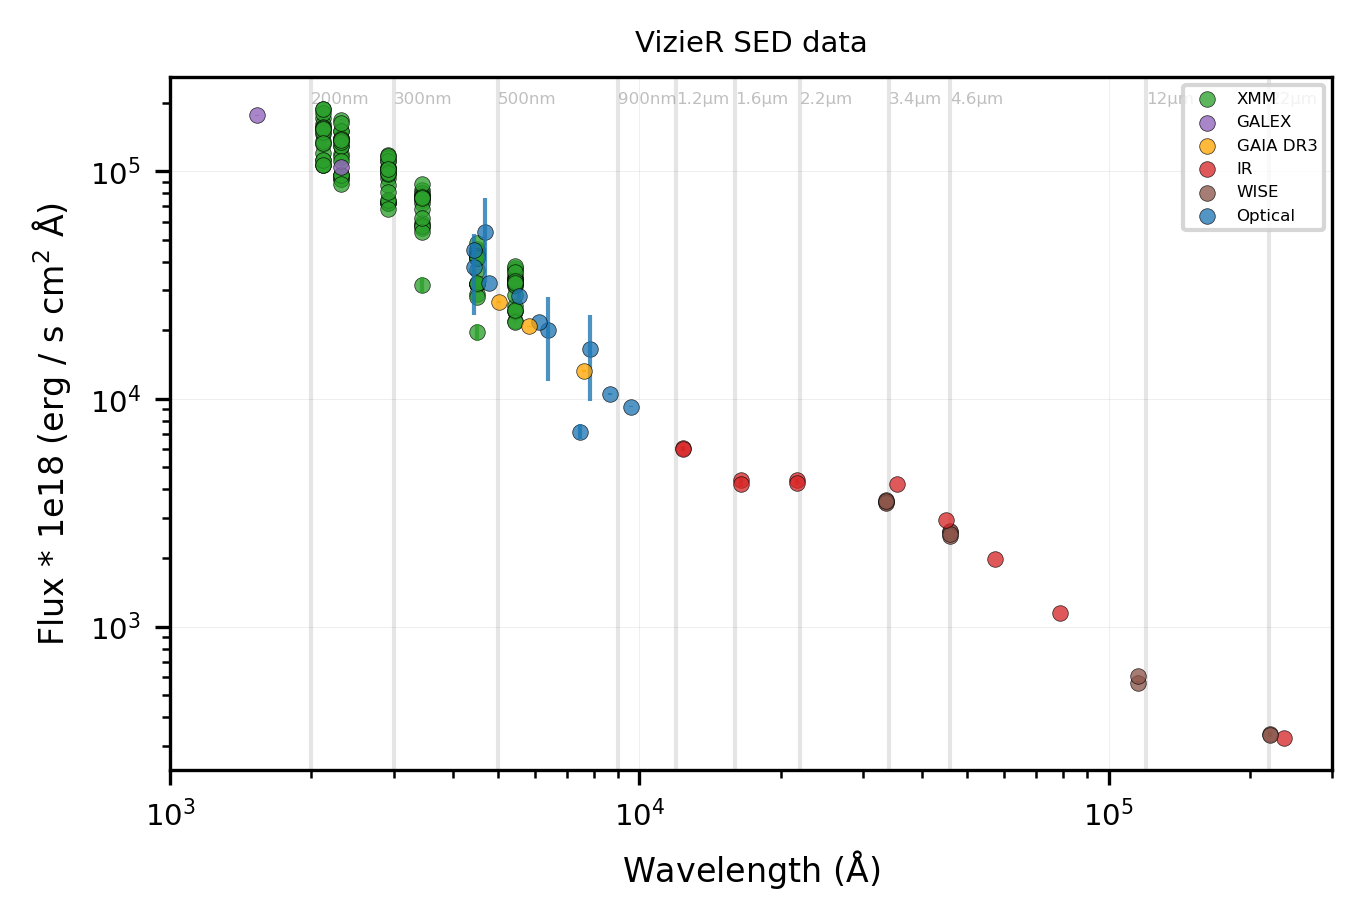

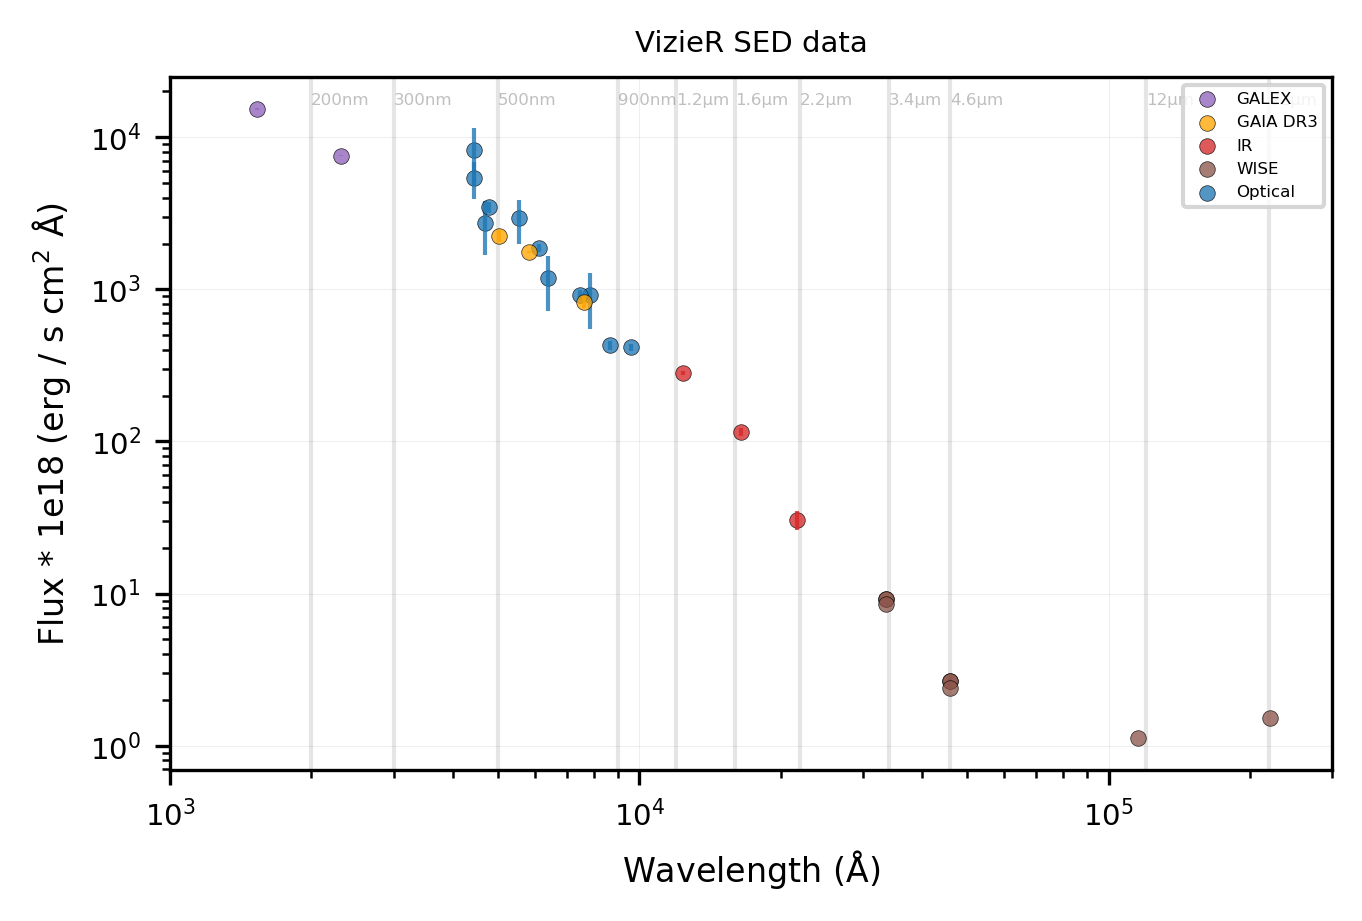

In [2]:
def plot_sed(data, ifshow=False, save_path=None):
    # 读取process_flux()筛选过的数据
    sed = Table.read(data) # 读取下载好的sed数据
    #sed = process_flux(tbl)
    #print(sed)
    vizr_wave,vizr_flux,vizr_eflux,vizr_filter = sed['vizr_wave'],sed['vizr_flux'],sed['vizr_eflux'],sed['vizr_filter']
    vizr_flux = vizr_flux*1e18
    vizr_eflux = vizr_eflux*1e18
    
    plots = []
    plotnames=[]
    p1,p2,p3,p4,p5,p6 = 0,0,0,0,0,0
    
    f = plt.figure(figsize=(5,3),dpi=300)
    plt.grid(True, linewidth=0.2,alpha=0.16,c='grey',zorder=0)
    
    for k in range(len(vizr_wave)):
        #print(vizr_filter[k])
        if 'XMM' in vizr_filter[k]:
            p1 = plt.scatter(vizr_wave[k], vizr_flux[k]/vizr_wave[k],
                        marker='o',edgecolors='k', linewidths=0.18, s=14, alpha=0.77, c='tab:green',zorder=4)
            plt.errorbar(vizr_wave[k],vizr_flux[k]/vizr_wave[k],yerr=vizr_eflux[k]/vizr_wave[k],
                         elinewidth=1,capsize=0,capthick=1,alpha=0.8,c='tab:green',zorder=4)

        elif 'GALEX' in vizr_filter[k]:
            p2 = plt.scatter(vizr_wave[k], vizr_flux[k]/vizr_wave[k],
                        marker='o',edgecolors='k', linewidths=0.18, s=14, alpha=0.8,c='tab:purple',zorder=5)
            plt.errorbar(vizr_wave[k],vizr_flux[k]/vizr_wave[k],yerr=vizr_eflux[k]/vizr_wave[k],
                         elinewidth=1,capsize=0,capthick=1,alpha=0.8,c='tab:purple',zorder=5)

        elif 'GAIA3' in vizr_filter[k]:
            p3 = plt.scatter(vizr_wave[k], vizr_flux[k]/vizr_wave[k],
                        marker='o',edgecolors='k', linewidths=0.18, s=14, alpha=0.77,c='orange',zorder=6)
            plt.errorbar(vizr_wave[k],vizr_flux[k]/vizr_wave[k],yerr=vizr_eflux[k]/vizr_wave[k],
                         elinewidth=1,capsize=0,capthick=1,alpha=0.8,c='orange',zorder=6)

        elif '2MASS' in vizr_filter[k] or 'Spitzer' in vizr_filter[k]:
            p4 = plt.scatter(vizr_wave[k], vizr_flux[k]/vizr_wave[k],
                        marker='o',edgecolors='k', linewidths=0.18, s=14, alpha=0.77,c='tab:red',zorder=4)
            plt.errorbar(vizr_wave[k],vizr_flux[k]/vizr_wave[k],yerr=vizr_eflux[k]/vizr_wave[k],
                         elinewidth=1,capsize=0,capthick=1,alpha=0.8,c='tab:red',zorder=4)

        elif 'WISE' in vizr_filter[k]:
            p5 = plt.scatter(vizr_wave[k], vizr_flux[k]/vizr_wave[k],
                        marker='o',edgecolors='k', linewidths=0.18, s=14, alpha=0.77,c='tab:brown',zorder=4)
            plt.errorbar(vizr_wave[k],vizr_flux[k]/vizr_wave[k],yerr=vizr_eflux[k]/vizr_wave[k],
                         elinewidth=1,capsize=0,capthick=1,alpha=0.8,c='tab:brown',zorder=4)

        else:
            p6 = plt.scatter(vizr_wave[k], vizr_flux[k]/vizr_wave[k],
                        marker='o',edgecolors='k', linewidths=0.18, s=14, alpha=0.77,c='tab:blue',zorder=5)
            plt.errorbar(vizr_wave[k],vizr_flux[k]/vizr_wave[k],yerr=vizr_eflux[k]/vizr_wave[k],
                         elinewidth=1,capsize=0,capthick=1,alpha=0.8,c='tab:blue',zorder=5)
    if p1!=0:
        plots.append(p1)
        plotnames.append('XMM')
    if p2!=0:    
        plots.append(p2)
        plotnames.append('GALEX')
    if p3!=0:        
        plots.append(p3)
        plotnames.append('GAIA DR3')
    if p4!=0:        
        plots.append(p4)
        plotnames.append('IR')
    if p5!=0:        
        plots.append(p5)
        plotnames.append('WISE')
    if p6!=0:        
        plots.append(p6)
        plotnames.append('Optical')
    #print(plotnames)

    
    aa = [2000,    3000,5000,9000, 12000,16000,22000, 34000,46000,120000,220000]
    bb = ['200nm', '300nm','500nm','900nm', '1.2μm','1.6μm','2.2μm', '3.4μm','4.6μm','12μm','22μm']
    ax = plt.gca()
    y1,y2 = ax.get_ylim()
    # print('y1 y2', y1,y2)
    # yrange = (y2 - y1)
    # print('yrange', yrange)
    # print('y log',(y1 + 0.02*yrange))
    # texty = (y1 + 0.02*yrange)
    # print('y line', texty)

    for i in range(len(aa)):
        plt.axvline(x=aa[i],linewidth=1,alpha=0.2,c='gray',zorder=1)
        plt.text(aa[i],y2,bb[i],zorder=1,alpha=0.5,c='gray',fontsize=4.)

    
    plt.ylabel(r'Flux * 1e18 ($\rm{erg\ /\ s\ cm^{2}\ \AA}$)', fontsize=8.)
    plt.xlabel(r'Wavelength ($\rm{\AA}$)', fontsize=8.)
    plt.xlim(1000,300000)
    plt.xscale('log')
    plt.xticks(fontsize=7)
    plt.yticks(fontsize=7)
    plt.yscale('log')
    plt.legend(plots,plotnames,loc='upper right',fontsize=4.)
    plt.title('VizieR SED data', fontsize=7)
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    if ifshow:
        plt.show()

    plt.close(f)
    plt.close('all')
    
#plot_sed('./Temp/3C_273/sed_vizier_processed.csv', ifshow=True, save_path='./Temp/SED_plot_test4.png')
#plot_sed('./Temp/sed_vizier_processed.csv', ifshow=True, save_path='./Temp/SED_plot_test5.png')